In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt

In [ ]:
# Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten images (28x28 → 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Training shape:", x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 784)


**Function to Plot Loss & Accuracy**

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title + " - Loss")
    plt.legend(['Train','Validation'])

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title + " - Accuracy")
    plt.legend(['Train','Validation'])

    plt.show()

**Baseline Model (No Regularization)**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8699 - loss: 0.4554 - val_accuracy: 0.9609 - val_loss: 0.1294
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9653 - loss: 0.1130 - val_accuracy: 0.9700 - val_loss: 0.1021
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9781 - loss: 0.0728 - val_accuracy: 0.9714 - val_loss: 0.0941
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9833 - loss: 0.0545 - val_accuracy: 0.9742 - val_loss: 0.0908
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9864 - loss: 0.0408 - val_accuracy: 0.9737 - val_loss: 0.0875
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9903 - loss: 0.0313 - val_accuracy: 0.9715 - val_loss: 0.1088
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9907 - loss: 0.0267 - val_accuracy: 0.9726 - val_loss: 0.1001
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9925 - loss: 0.0234 - 

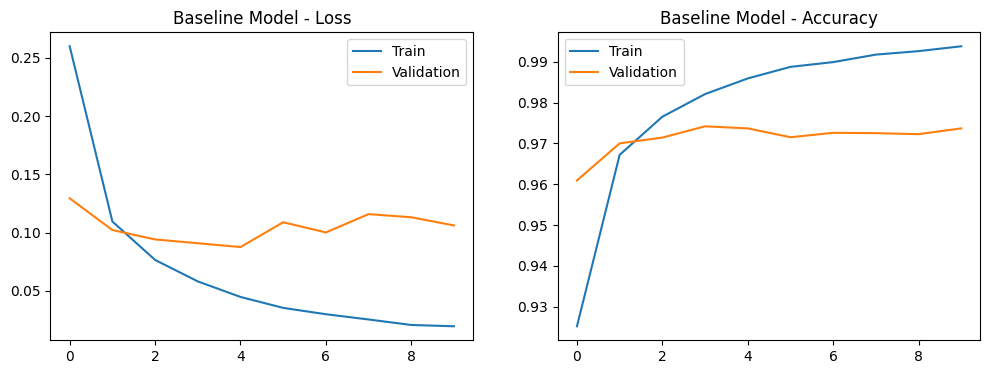

In [ ]:
baseline_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

plot_history(history_baseline, "Baseline Model")

**Model with Dropout**

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6813 - loss: 0.9791 - val_accuracy: 0.9416 - val_loss: 0.2048
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8975 - loss: 0.3627 - val_accuracy: 0.9574 - val_loss: 0.1534
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9193 - loss: 0.2828 - val_accuracy: 0.9602 - val_loss: 0.1401
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9300 - loss: 0.2507 - val_accuracy: 0.9647 - val_loss: 0.1261
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9357 - loss: 0.2327 - val_accuracy: 0.9673 - val_loss: 0.1196
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9391 - loss: 0.2112 - val_accuracy: 0.9669 - val_loss: 0.1236
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9433 - loss: 0.2064 - val_accuracy: 0.9631 - val_loss: 0.1307
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9446 - loss: 0.1950 - 

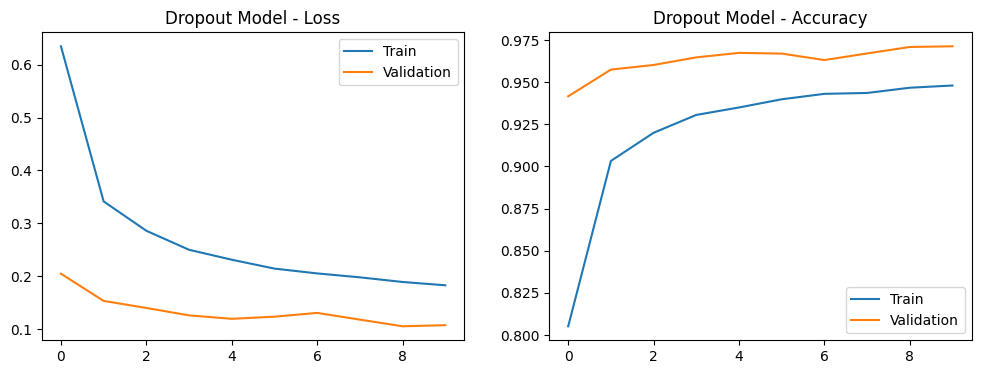

In [ ]:
dropout_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

dropout_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_dropout = dropout_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

plot_history(history_dropout, "Dropout Model")

**Model with L2 Regularization**

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8534 - loss: 0.6893 - val_accuracy: 0.9536 - val_loss: 0.3029
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9569 - loss: 0.2875 - val_accuracy: 0.9618 - val_loss: 0.2539
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9660 - loss: 0.2375 - val_accuracy: 0.9645 - val_loss: 0.2290
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9686 - loss: 0.2118 - val_accuracy: 0.9613 - val_loss: 0.2340
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9705 - loss: 0.1993 - val_accuracy: 0.9580 - val_loss: 0.2361
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9722 - loss: 0.1892 - val_accuracy: 0.9655 - val_loss: 0.2057
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9746 - loss: 0.1786 - val_accuracy: 0.9690 - val_loss: 0.1968
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9746 - loss: 0.1709 - 

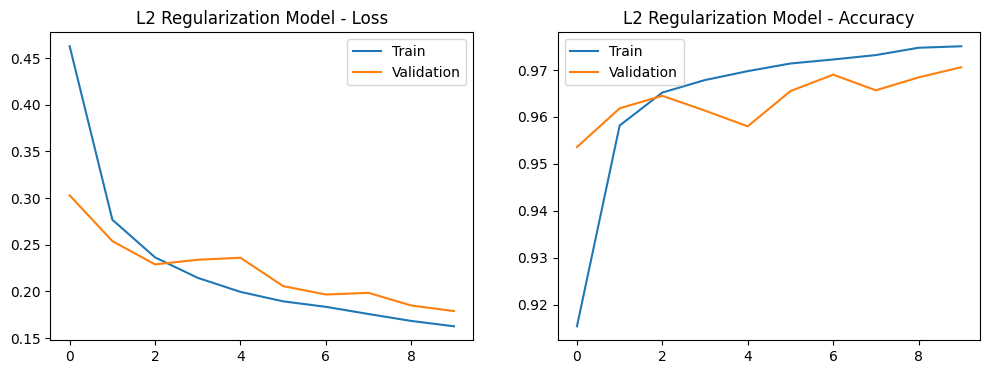

In [ ]:
l2_model = keras.Sequential([
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001),
                 input_shape=(784,)),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(10, activation='softmax')
])

l2_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_l2 = l2_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

plot_history(history_l2, "L2 Regularization Model")

**Model with Batch Normalization**

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8656 - loss: 0.4472 - val_accuracy: 0.9567 - val_loss: 0.1409
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9601 - loss: 0.1290 - val_accuracy: 0.9643 - val_loss: 0.1158
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9695 - loss: 0.0944 - val_accuracy: 0.9718 - val_loss: 0.0945
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9764 - loss: 0.0736 - val_accuracy: 0.9706 - val_loss: 0.1030
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9781 - loss: 0.0685 - val_accuracy: 0.9723 - val_loss: 0.0978
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9815 - loss: 0.0562 - val_accuracy: 0.9744 - val_loss: 0.0915
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9838 - loss: 0.0516 - val_accuracy: 0.9748 - val_loss: 0.0875
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9855 - loss: 0.0419 -

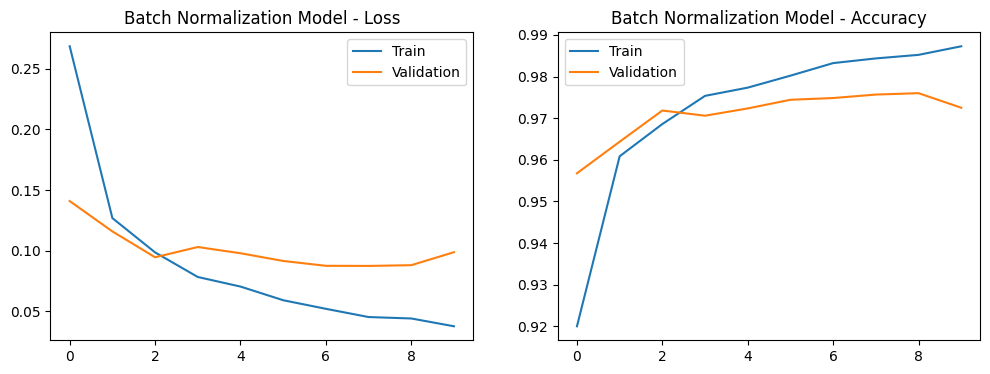

In [ ]:
bn_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(10, activation='softmax')
])

bn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_bn = bn_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

plot_history(history_bn, "Batch Normalization Model")

**Simple Comparison Table**

In [ ]:
print("Baseline Final Val Accuracy:", history_baseline.history['val_accuracy'][-1])
print("Dropout Final Val Accuracy:", history_dropout.history['val_accuracy'][-1])
print("L2 Final Val Accuracy:", history_l2.history['val_accuracy'][-1])
print("BatchNorm Final Val Accuracy:", history_bn.history['val_accuracy'][-1])

Baseline Final Val Accuracy: 0.9736666679382324
Dropout Final Val Accuracy: 0.9712499976158142
L2 Final Val Accuracy: 0.9705833196640015
BatchNorm Final Val Accuracy: 0.9725000262260437
